<a href="https://colab.research.google.com/github/castrokelly/PPGIa/blob/main/transformer_classificacao_sentimentos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fine-tuning de um Transformer para Classificação Binária (Positiva/Negativa)

In [1]:
!pip install -q "transformers==4.38.2" "tf-keras" datasets scikit-learn pandas matplotlib

In [2]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import pandas as pd
import string
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from transformers import BertTokenizer
import tensorflow as tf

## Carregamento e limpeza dos dados

In [3]:
df1 = pd.read_csv("g1_v1_ws.csv", sep=';', encoding='ISO-8859-1')
df2 = pd.read_csv("g1_v2_ws.csv", sep=';', encoding='ISO-8859-1')
df = pd.concat([df1, df2], ignore_index=True)
df.columns = [col.strip() for col in df.columns]
df['texto'] = df['texto'].str.strip()
df['classe'] = df['classe'].str.strip()
n_labels=len(df['classe'].unique())
print('Labels:', n_labels)
df.head()

Labels: 7


,texto,;,classe
0,Ney Latorraca melhora e pode deixar CTI na sem...,;,alegria
1,Rato é encontrado em lata de feijões na França...,;,surpresa
2,Cientistas criam câmera mais rápida do mundo F...,;,alegria
3,Programa em MG aumenta uso de métodos anticonc...,;,alegria
4,"Alencar é transferido para quarto, diz boletim...",;,alegria


## Conversão das classes para binárias (positiva/negativa)

In [4]:
positivas = ['alegria', 'surpresa']
df['classe_binaria'] = df['classe'].apply(lambda x: 'positiva' if x in positivas else 'negativa')
print('Classes:', df['classe'].unique())
print('Classes binárias:', df['classe_binaria'].unique())
num_labels=2

Classes: ['alegria' 'surpresa' 'desgosto' 'medo' 'raiva' 'tristeza' 'neutro']
Classes binárias: ['positiva' 'negativa']


## Pré-processamento textual

In [5]:
stopwords_pt = {'a', 'à', 'ao', 'aos', 'as', 'às', 'com', 'da', 'das', 'de', 'do', 'dos', 'e', 'é', 'em', 'na', 'nas', 'no', 'nos', 'num', 'numa', 'o', 'os', 'para', 'por', 'que', 'se', 'sem', 'ser', 'tem', 'têm', 'um', 'uma', 'uns', 'umas', 'vai', 'já', 'como', 'mas', 'não', 'foi', 'são', 'também', 'muito', 'há', 'está', 'estavam', 'estava', 'estavam', 'estive', 'estivemos', 'fui', 'fomos', 'isso', 'era', 'eram', 'sou', 'somos', 'estou', 'tive', 'teve', 'tivemos', 'foram', 'porque', 'quando', 'onde', 'quem', 'qual', 'quais'}
def preprocess(texto):
    texto = texto.lower()
    texto = ''.join(c for c in texto if c not in string.punctuation)
    tokens = texto.split()
    return ' '.join(t for t in tokens if t not in stopwords_pt)
df['texto_limpo'] = df['texto'].apply(preprocess)

## Tokenização com BERT e divisão dos dados

In [6]:
X_train, X_test, y_train, y_test = train_test_split(df['texto_limpo'], df['classe_binaria'], test_size=0.2, stratify=df['classe'], random_state=42)
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

#tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-cased')
tokenizer = BertTokenizer.from_pretrained("neuralmind/bert-base-portuguese-cased")
train_encodings = tokenizer(list(X_train), truncation=True, padding=True, max_length=128, return_tensors='tf')
test_encodings = tokenizer(list(X_test), truncation=True, padding=True, max_length=128, return_tensors='tf')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


## Treinamento com TensorFlow/Keras

In [7]:
from transformers import TFBertModel
import tensorflow as tf

train_dataset = tf.data.Dataset.from_tensor_slices((dict(train_encodings), y_train_enc)).batch(16)
test_dataset = tf.data.Dataset.from_tensor_slices((dict(test_encodings), y_test_enc)).batch(16)

# Load pretrained BERT
bert = TFBertModel.from_pretrained('neuralmind/bert-base-portuguese-cased')
#bert.trainable = False  # Optional: freeze BERT

# Input layers
input_ids = tf.keras.Input(shape=(None,), dtype=tf.int32, name="input_ids")
attention_mask = tf.keras.Input(shape=(None,), dtype=tf.int32, name="attention_mask")


# BERT outputs
bert_outputs = bert({"input_ids": input_ids, "attention_mask": attention_mask})
cls_output = bert_outputs.pooler_output  # [CLS] token output

# Custom classification head
x = tf.keras.layers.Dense(256, activation="relu")(cls_output)
x = tf.keras.layers.Dropout(0.3)(x)
x = tf.keras.layers.Dense(64, activation="relu")(x)
x = tf.keras.layers.Dropout(0.2)(x)
output = tf.keras.layers.Dense(num_labels, activation="softmax")(x)

# Final model
model = tf.keras.Model(inputs=[input_ids, attention_mask], outputs=output)

# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"]
)

model.summary()

Some layers from the model checkpoint at neuralmind/bert-base-portuguese-cased were not used when initializing TFBertModel: ['mlm___cls']
- This IS expected if you are initializing TFBertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some layers of TFBertModel were not initialized from the model checkpoint at neuralmind/bert-base-portuguese-cased and are newly initialized: ['bert/pooler/dense/kernel:0', 'bert/pooler/dense/bias:0']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 attention_mask (InputLayer  [(None, None)]               0         []                            
 )                                                                                                
                                                                                                  
 input_ids (InputLayer)      [(None, None)]               0         []                            
                                                                                                  
 tf_bert_model (TFBertModel  TFBaseModelOutputWithPooli   1089231   ['attention_mask[0][0]',      
 )                           ngAndCrossAttentions(last_   36         'input_ids[0][0]']           
                             hidden_state=(None, None,                                        

In [8]:
model.fit(train_dataset, epochs=20, validation_data=test_dataset)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/functional.py:641: UserWarning: Input dict contained keys ['token_type_ids'] which did not match any model input. They will be ignored by the model.
  inputs = self._flatten_to_reference_inputs(inputs)


137/137 [==============================] - 112s 420ms/step - loss: 0.5205 - accuracy: 0.7451 - val_loss: 0.4391 - val_accuracy: 0.7934
Epoch 2/20
137/137 [==============================] - 56s 409ms/step - loss: 0.3501 - accuracy: 0.8545 - val_loss: 0.5085 - val_accuracy: 0.8099
Epoch 3/20
137/137 [==============================] - 57s 414ms/step - loss: 0.2621 - accuracy: 0.9011 - val_loss: 0.5990 - val_accuracy: 0.8190
Epoch 4/20
137/137 [==============================] - 56s 409ms/step - loss: 0.2123 - accuracy: 0.9117 - val_loss: 0.6136 - val_accuracy: 0.8355
Epoch 5/20
137/137 [==============================] - 56s 410ms/step - loss: 0.1636 - accuracy: 0.9295 - val_loss: 0.6548 - val_accuracy: 0.8373
Epoch 6/20
137/137 [==============================] - 57s 414ms/step - loss: 0.1356 - accuracy: 0.9272 - val_loss: 0.7544 - val_accuracy: 0.8245
Epoch 7/20
137/137 [==============================] - 56s 406ms/step - loss: 0.1277 - accuracy: 0.9277 - val_loss: 0.9787 - val_accuracy: 0.

## Avaliação com scikit-learn

In [9]:
import numpy as np
y_pred_logits = model.predict(test_dataset)
y_pred = np.argmax(y_pred_logits, axis=1)
print(classification_report(y_test_enc, y_pred, target_names=label_encoder.classes_))

35/35 [==============================] - 7s 136ms/step
              precision    recall  f1-score   support

    negativa       0.88      0.88      0.88       370
    positiva       0.75      0.75      0.75       177

    accuracy                           0.84       547
   macro avg       0.81      0.81      0.81       547
weighted avg       0.84      0.84      0.84       547



Matriz de Confusão

35/35 [==============================] - 5s 130ms/step


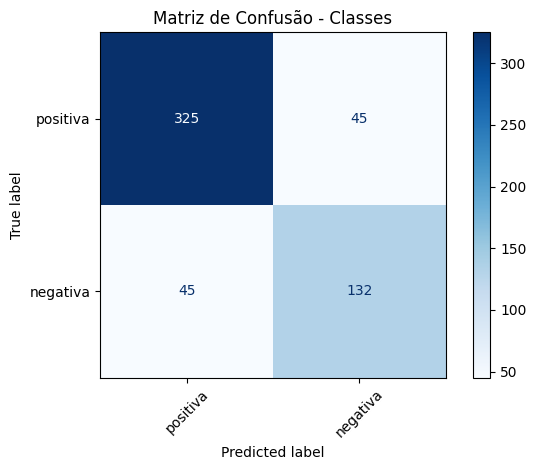

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Previsões
logits = model.predict(test_dataset)
y_pred = np.argmax(logits, axis=1)

# Gerar matriz de confusão
cm = confusion_matrix(y_test_enc, y_pred)
labels = label_encoder.classes_

# Visualizar
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Matriz de Confusão - Classes")
plt.tight_layout()
plt.show()

Imprimindo Exemplos


In [11]:
y_pred_labels = label_encoder.inverse_transform(y_pred)
y_true_labels = label_encoder.inverse_transform(y_test_enc)

# Criar DataFrame para visualização
df_resultados = pd.DataFrame({
    "frase": X_test.reset_index(drop=True),
    "classe_verdadeira": y_true_labels,
    "classe_predita": y_pred_labels
})

# Mostrar 10 exemplos aleatórios
df_resultados.sample(10)

,frase,classe_verdadeira,classe_predita
345,usp unicamp unesp adiam início aulas causa nov...,negativa,negativa
133,crosta estrela 10 bilhões vezes mais forte aço...,negativa,positiva
54,crise econômica agrava situação direitos human...,negativa,positiva
293,aquecimento global beneficiou império inca diz...,positiva,positiva
124,pf investiga despejo lixo vindo europa portos ...,negativa,negativa
537,trégua faixa gaza entra vigor 17h diz egito fu...,positiva,positiva
480,organização mundial saúde enviar remédio contr...,positiva,positiva
24,senador piauí sofre cirurgia redução estômago ...,positiva,positiva
254,avalanche mata 6 turistas estação esqui alpes ...,negativa,negativa
503,ladrões fazem arrastões restaurante igreja eva...,negativa,negativa


## Discussão dos resultados

O experimento realizou o **fine-tuning de um Transformer/BERT** para a tarefa de **classificação binária de sentimentos**, classificando manchetes/textos como **positivos** ou **negativos**. As classes originais da base eram `alegria`, `surpresa`, `desgosto`, `medo`, `raiva`, `tristeza` e `neutro`. Para a tarefa binária, as classes `alegria` e `surpresa` foram agrupadas como **positiva**, enquanto as demais foram agrupadas como **negativa**.

O modelo utilizado foi o **BERTimbau** (`neuralmind/bert-base-portuguese-cased`), um modelo BERT pré-treinado para português. Após a tokenização dos textos, as representações contextuais extraídas pelo BERT foram passadas para uma cabeça de classificação composta por camadas densas, dropout e uma camada final `softmax` com duas saídas.

No conjunto de teste, o modelo apresentou os seguintes resultados:

| Classe       | Precision | Recall | F1-score | Support |
| ------------ | --------: | -----: | -------: | ------: |
| negativa     |      0.88 |   0.88 |     0.88 |     370 |
| positiva     |      0.75 |   0.75 |     0.75 |     177 |
| accuracy     |           |        |     0.84 |     547 |
| macro avg    |      0.81 |   0.81 |     0.81 |     547 |
| weighted avg |      0.84 |   0.84 |     0.84 |     547 |

A acurácia geral foi de **0,84**, indicando que o modelo classificou corretamente cerca de **84%** dos exemplos do conjunto de teste. O F1-score ponderado também foi **0,84**, o que mostra um desempenho geral consistente.

A matriz de confusão obtida foi:


\begin{bmatrix}
325 & 45 \\
45 & 132
\end{bmatrix}  

Considerando a ordem das classes codificadas pelo `LabelEncoder`, isso indica que:  

* **325 textos negativos** foram classificados corretamente como negativos;
* **132 textos positivos** foram classificados corretamente como positivos;
* **45 textos negativos** foram classificados incorretamente como positivos;
* **45 textos positivos** foram classificados incorretamente como negativos.

Apesar de o número absoluto de erros ser igual nas duas direções, o impacto relativo é maior na classe **positiva**, porque essa classe possui menos exemplos no conjunto de teste. A classe negativa possui **370 exemplos**, enquanto a classe positiva possui **177 exemplos**. Portanto, há um **desequilíbrio entre as classes**, com predominância de textos negativos.  

Por esse motivo, a acurácia isolada não é suficiente para avaliar o modelo. O **F1-score por classe** é mais informativo. A classe negativa apresentou F1-score de **0,88**, enquanto a classe positiva apresentou F1-score de **0,75**. Isso indica que o modelo reconhece melhor os textos negativos do que os positivos.  

A análise dos exemplos classificados mostra que alguns erros fazem sentido do ponto de vista semântico. Manchetes com conteúdo científico, acontecimentos inesperados ou situações ambíguas podem ser confundidas com textos positivos, especialmente quando se aproximam de `surpresa` ou `alegria`. Por exemplo, manchetes sobre descobertas científicas ou eventos incomuns podem carregar tom de novidade, mesmo quando a classe original foi agrupada como negativa. Também há casos em que textos com termos negativos, como crise ou problemas sociais, podem ser confundidos dependendo do contexto da frase.

Durante o treinamento, observou-se que a acurácia de treino aumentou ao longo das épocas, enquanto a perda de validação também aumentou nas épocas finais. Esse comportamento sugere possível **sobreajuste** após algumas épocas. Portanto, em uma versão aprimorada do experimento, seria recomendável usar `EarlyStopping`, reduzir o número de épocas ou congelar parcialmente o BERT nas primeiras rodadas de treinamento.

Conclui-se que o Transformer/BERT conseguiu diferenciar razoavelmente bem frases positivas e negativas, com desempenho geral satisfatório. No entanto, o modelo apresentou maior dificuldade na classe positiva, provavelmente devido ao menor número de exemplos e à ambiguidade semântica de algumas manchetes. Assim, o F1-score por classe e a matriz de confusão são mais importantes do que a acurácia isolada para interpretar corretamente o desempenho do classificador.
